## 1
Utilize o dataset Iris para a computar a matriz de distância entre todos os os objetos, considerando todas as features. Utilize a distância euclideana para essa tarefa.

In [1]:
import pandas as pd


dfIris = pd.read_csv('Iris.csv').set_index('Id')

print(dfIris)

#A coluna Species não deve ser considerada no cálculo de distâncias, pois ela representa o rótulo dos objetos.

     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm         Species
Id                                                                           
1              5.1           3.5            1.4           0.2     Iris-setosa
2              4.9           3.0            1.4           0.2     Iris-setosa
3              4.7           3.2            1.3           0.2     Iris-setosa
4              4.6           3.1            1.5           0.2     Iris-setosa
5              5.0           3.6            1.4           0.2     Iris-setosa
..             ...           ...            ...           ...             ...
146            6.7           3.0            5.2           2.3  Iris-virginica
147            6.3           2.5            5.0           1.9  Iris-virginica
148            6.5           3.0            5.2           2.0  Iris-virginica
149            6.2           3.4            5.4           2.3  Iris-virginica
150            5.9           3.0            5.1           1.8  I

In [2]:
from sklearn.metrics.pairwise import euclidean_distances

euclidean_distances(dfIris.iloc[:,0:4])

array([[0.        , 0.53851648, 0.50990195, ..., 4.45982062, 4.65080638,
        4.14004831],
       [0.53851648, 0.        , 0.3       , ..., 4.49888875, 4.71805044,
        4.15331193],
       [0.50990195, 0.3       , 0.        , ..., 4.66154481, 4.84871117,
        4.29883705],
       ...,
       [4.45982062, 4.49888875, 4.66154481, ..., 0.        , 0.6164414 ,
        0.64031242],
       [4.65080638, 4.71805044, 4.84871117, ..., 0.6164414 , 0.        ,
        0.76811457],
       [4.14004831, 4.15331193, 4.29883705, ..., 0.64031242, 0.76811457,
        0.        ]])

## 2
Utilize o dataset Titanic e faça o que se pede.<br><br>

a) Identifique quais colunas possuem dados nulos (ou NaN).<br>
b) Remova todas as colunas que possuem dados nulos (ou NaN).<br>
c) Calcule a similaridade do cosseno para todos os objetos. Lembre-se de fazer o devido tratamento para os tipos de dados presentes nesse dataset. Você também pode desconsiderar a coluna survived.<br>
d) Calcule a distância euclideana para todos os objetos. Você também pode desconsiderar a coluna survived.


In [3]:
#2a
import seaborn as sns 

dataset = sns.load_dataset('titanic')
dataset.isnull().any()

survived       False
pclass         False
sex            False
age             True
sibsp          False
parch          False
fare           False
embarked        True
class          False
who            False
adult_male     False
deck            True
embark_town     True
alive          False
alone          False
dtype: bool

In [4]:
#2b

#O copy() faz uma cópia do dataframe original e evita trabalhar com uma referência ao anterior.
dataset_clean = dataset.dropna(axis=1).copy()
dataset_clean

,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alive,alone
0,0,3,male,1,0,7.2500,Third,man,True,no,False
1,1,1,female,1,0,71.2833,First,woman,False,yes,False
2,1,3,female,0,0,7.9250,Third,woman,False,yes,True
3,1,1,female,1,0,53.1000,First,woman,False,yes,False
4,0,3,male,0,0,8.0500,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,0,0,13.0000,Second,man,True,no,True
887,1,1,female,0,0,30.0000,First,woman,False,yes,True
888,0,3,female,1,2,23.4500,Third,woman,False,no,False
889,1,1,male,0,0,30.0000,First,man,True,yes,True


In [5]:
#2c

dataset_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   survived    891 non-null    int64   
 1   pclass      891 non-null    int64   
 2   sex         891 non-null    object  
 3   sibsp       891 non-null    int64   
 4   parch       891 non-null    int64   
 5   fare        891 non-null    float64 
 6   class       891 non-null    category
 7   who         891 non-null    object  
 8   adult_male  891 non-null    bool    
 9   alive       891 non-null    object  
 10  alone       891 non-null    bool    
dtypes: bool(2), category(1), float64(1), int64(4), object(3)
memory usage: 58.6+ KB


In [6]:
dataset_clean['sex'] = dataset_clean['sex'].astype('category')
dataset_clean['sex'] = dataset_clean['sex'].cat.codes

dataset_clean['class'] = dataset_clean['class'].astype('category')
dataset_clean['class'] = dataset_clean['class'].cat.codes

dataset_clean['who'] = dataset_clean['who'].astype('category')
dataset_clean['who'] = dataset_clean['who'].cat.codes

dataset_clean['adult_male'] = dataset_clean['adult_male'].astype('category')
dataset_clean['adult_male'] = dataset_clean['adult_male'].cat.codes

dataset_clean['alive'] = dataset_clean['alive'].astype('category')
dataset_clean['alive'] = dataset_clean['alive'].cat.codes

dataset_clean['alone'] = dataset_clean['alone'].astype('category')
dataset_clean['alone'] = dataset_clean['alone'].cat.codes

from sklearn.metrics.pairwise import cosine_similarity

matrizCosse = cosine_similarity(dataset_clean.iloc[:,1:])
matrizCosse

array([[1.        , 0.87874834, 0.96049847, ..., 0.93259598, 0.8902784 ,
        0.9859454 ],
       [0.87874834, 1.        , 0.88800576, ..., 0.98459228, 0.99786042,
        0.89021353],
       [0.96049847, 0.88800576, 1.        , ..., 0.9377859 , 0.89901517,
        0.97506378],
       ...,
       [0.93259598, 0.98459228, 0.9377859 , ..., 1.        , 0.98427116,
        0.93714028],
       [0.8902784 , 0.99786042, 0.89901517, ..., 0.98427116, 1.        ,
        0.90639995],
       [0.9859454 , 0.89021353, 0.97506378, ..., 0.93714028, 0.90639995,
        1.        ]])

In [7]:
#2d
matrizEucli = euclidean_distances(dataset_clean.iloc[:,1:])
matrizCosse

array([[1.        , 0.87874834, 0.96049847, ..., 0.93259598, 0.8902784 ,
        0.9859454 ],
       [0.87874834, 1.        , 0.88800576, ..., 0.98459228, 0.99786042,
        0.89021353],
       [0.96049847, 0.88800576, 1.        , ..., 0.9377859 , 0.89901517,
        0.97506378],
       ...,
       [0.93259598, 0.98459228, 0.9377859 , ..., 1.        , 0.98427116,
        0.93714028],
       [0.8902784 , 0.99786042, 0.89901517, ..., 0.98427116, 1.        ,
        0.90639995],
       [0.9859454 , 0.89021353, 0.97506378, ..., 0.93714028, 0.90639995,
        1.        ]])

# 3
De posse da matrizes obtidas nas questões 2c e 2d, faça o que se pede.<br><br>

a) Mostre os valores de similaridade de cosseno do objeto 0 para o 3 e 200.<br>
b) Mostre os valores de distância Euclideana do objeto 0 para o 3 e 200.<br>
c) Analise os dados originais para esses objetos. A similaridade do cosseno e a distância euclideana fazem sentido para você nesses resultados? Explique a sua resposta.<br>


In [8]:
#3a
print(matrizCosse[0,3])
print(matrizCosse[0,200])

0.8817154522100574
0.9826379798988352


In [9]:
#3b
print(matrizEucli[0,3])
print(matrizEucli[0,200])

45.98067528864708
2.6575364531836625


In [10]:
#3c
print(dataset.iloc[0,:])
print(dataset.iloc[3,:])
print(dataset.iloc[200,:])

survived                 0
pclass                   3
sex                   male
age                   22.0
sibsp                    1
parch                    0
fare                  7.25
embarked                 S
class                Third
who                    man
adult_male            True
deck                   NaN
embark_town    Southampton
alive                   no
alone                False
Name: 0, dtype: object
survived                 1
pclass                   1
sex                 female
age                   35.0
sibsp                    1
parch                    0
fare                  53.1
embarked                 S
class                First
who                  woman
adult_male           False
deck                     C
embark_town    Southampton
alive                  yes
alone                False
Name: 3, dtype: object
survived                 0
pclass                   3
sex                   male
age                   28.0
sibsp                    0
parch    

Como pode ser observado nas saídas acima, intuitivamente faz mais sentido o objeto 0 ser mais próximo do 200 em vez do 3. Podemos ver isso pelo número maior de atributos semelhantes. Sendo assim, a similaridade do cosseno e a distância euclideana estão capturando esse fato que está sendo observado.

## 4 

a) De posse do dataset prepreprocessado na questão 2, utilize a técnica PCA para identificar os dois primeiros componenetes principais (ou seja, PC1 e PC2). Não se esqueça de ignorar a coluna Survived. <br>

b) Visualize os objetos nas dimensões representadas pelo PC1 e PC2. Utilize a coluna 'survided' para colorir os objetos.<br>


c) Normalize os dados utilizando a normalização min-max. 

d) De posse desse novo conjunto normalizado, repita o passo 4b. A visualização mudou de forma significativa? Caso sim, o que pode ajudar a explicar essa diferença?

In [11]:
#4a

from sklearn.decomposition import PCA

# Nos dados originais
pca = PCA(n_components=2)
X = pca.fit_transform(dataset_clean.iloc[:,1:])

print(X)

[[-24.96496612   0.70375418]
 [ 39.10613779  -0.32898922]
 [-24.2884437   -0.26603364]
 ...
 [ -8.75442376   1.58690335]
 [ -2.18416738  -1.44217287]
 [-24.47124359  -0.31504644]]


<AxesSubplot:xlabel='PC1', ylabel='PC2'>

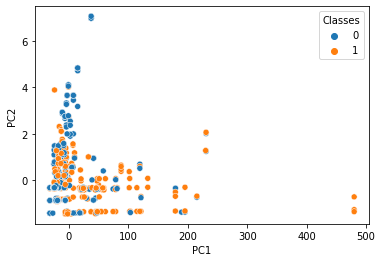

In [12]:
#4b
dfNoScale = pd.DataFrame(X, columns = ['PC1','PC2'])
dfNoScale['Classes'] = dataset_clean['survived']

sns.scatterplot(data=dfNoScale, x="PC1", y="PC2", hue='Classes', palette='tab10')

In [13]:
#4c
from sklearn import preprocessing

minmax_scaler = preprocessing.MinMaxScaler()
minmax = minmax_scaler.fit_transform(dataset_clean.iloc[:,1:])

pca = PCA(n_components=2)
X_norm = pca.fit_transform(minmax)

print(dataset_clean)
print(minmax)

     survived  pclass  sex  sibsp  parch     fare  class  who  adult_male  \
0           0       3    1      1      0   7.2500      2    1           1   
1           1       1    0      1      0  71.2833      0    2           0   
2           1       3    0      0      0   7.9250      2    2           0   
3           1       1    0      1      0  53.1000      0    2           0   
4           0       3    1      0      0   8.0500      2    1           1   
..        ...     ...  ...    ...    ...      ...    ...  ...         ...   
886         0       2    1      0      0  13.0000      1    1           1   
887         1       1    0      0      0  30.0000      0    2           0   
888         0       3    0      1      2  23.4500      2    2           0   
889         1       1    1      0      0  30.0000      0    1           1   
890         0       3    1      0      0   7.7500      2    1           1   

     alive  alone  
0        0      0  
1        1      0  
2        1     

<AxesSubplot:xlabel='PC1', ylabel='PC2'>

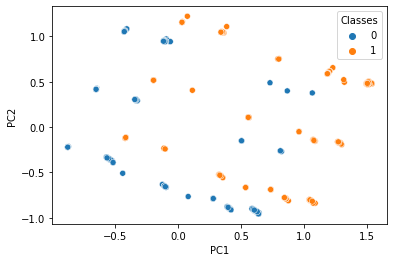

In [14]:
#4d

dfScale = pd.DataFrame(X_norm, columns = ['PC1','PC2'])
dfScale['Classes'] = dataset_clean['survived']

sns.scatterplot(data=dfScale, x="PC1", y="PC2", hue='Classes', palette='tab10')

Podemos observar que as visualizações ficaram significamente diferentes. Um fator que pode ajudar a explicar esse resultado é que a coluna Fare estava numa escala maior em relação às demais.